In [ ]:
# Install core packages (runs in a single Colab cell)
!pip install -q --upgrade pip
!pip install -q tensorflow scikit-learn matplotlib opencv-python-headless


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 26.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import sklearn, matplotlib
print("TensorFlow version:", tf.__version__)
print("scikit-learn version:", sklearn.__version__)
print("matplotlib version:", matplotlib.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs available:", gpus)
else:
    print("No GPUs visible to TensorFlow. Make sure Runtime -> Change runtime type -> GPU is selected.")


TensorFlow version: 2.19.0
scikit-learn version: 1.6.1
matplotlib version: 3.10.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harsha21005","key":"9a228dab7a234ccff9237b992860abe0"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d iarunava/cell-images-for-detecting-malaria -p /content/


Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown
 95% 640M/675M [00:02<00:00, 344MB/s]
100% 675M/675M [00:02<00:00, 247MB/s]


In [ ]:
!unzip -q /content/cell-images-for-detecting-malaria.zip -d /content/


In [ ]:
!rm -rf "/content/cell_images/cell_images"

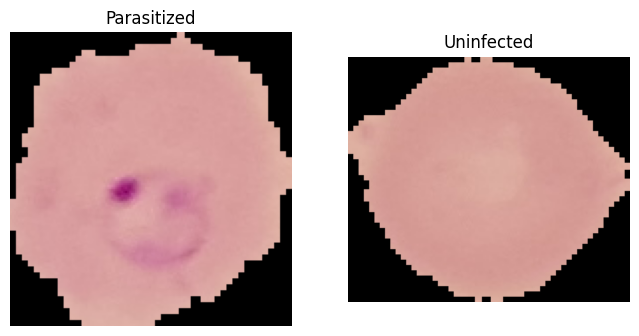

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/content/cell_images"

para = mpimg.imread("/content/cell_images/Parasitized/C100P61ThinF_IMG_20150918_144104_cell_162.png")
uninf = mpimg.imread("/content/cell_images/Uninfected/C100P61ThinF_IMG_20150918_144104_cell_128.png")

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(para)
plt.title("Parasitized")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(uninf)
plt.title("Uninfected")
plt.axis("off")

plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create a data generator for preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize pixel values (0–1)
    validation_split=0.2    # Split: 80% train, 20% validation
)

train_data = datagen.flow_from_directory(
    '/content/cell_images',
    target_size=(64, 64),   # Resize all images to 64x64
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    '/content/cell_images',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Step 4: Define a simple CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary output: 0 = Uninfected, 1 = Parasitized
])

# Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,281 (6.20 MB)

 Trainable params: 1,625,281 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


689/689 ━━━━━━━━━━━━━━━━━━━━ 33s 41ms/step - accuracy: 0.6731 - loss: 0.5869 - val_accuracy: 0.9143 - val_loss: 0.2552
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.9249 - loss: 0.2150 - val_accuracy: 0.9354 - val_loss: 0.1931
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.9509 - loss: 0.1554 - val_accuracy: 0.9276 - val_loss: 0.2022
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9581 - loss: 0.1304 - val_accuracy: 0.9350 - val_loss: 0.1890
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.9654 - loss: 0.1065 - val_accuracy: 0.9410 - val_loss: 0.1691


In [ ]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.9444 - loss: 0.1578
Validation Accuracy: 94.10%


In [ ]:
# ✅ Training generator with augmentation
train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,       # small random rotations
    width_shift_range=0.1,   # small horizontal shift
    height_shift_range=0.1,  # small vertical shift
    zoom_range=0.1,          # slight zoom
    horizontal_flip=True,    # random horizontal flips
    validation_split=0.2     # 80% train, 20% validation
)

# ✅ Validation generator (no augmentation)
val_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    '/content/cell_images',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = val_gen.flow_from_directory(
    '/content/cell_images',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),  # added one extra layer
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),  # reduced dropout slightly
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 59s 81ms/step - accuracy: 0.6499 - loss: 0.5803 - val_accuracy: 0.9314 - val_loss: 0.1953
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 79ms/step - accuracy: 0.9361 - loss: 0.1999 - val_accuracy: 0.9399 - val_loss: 0.2012
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9458 - loss: 0.1663 - val_accuracy: 0.9474 - val_loss: 0.1748
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9524 - loss: 0.1518 - val_accuracy: 0.9466 - val_loss: 0.1649
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9523 - loss: 0.1482 - val_accuracy: 0.9456 - val_loss: 0.1718
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 78ms/step - accuracy: 0.9530 - loss: 0.1404 - val_accuracy: 0.9483 - val_loss: 0.1591
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 53s 77ms/step - accuracy: 0.9547 - loss: 0.1387 - val_accuracy: 0.9485 - val_loss: 0.1554
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 54s 78ms/step - accuracy: 0.9572 - loss: 0.1316 - 

In [ ]:
val_loss, val_acc = model.evaluate(val_data)
print(f"Validation Accuracy: {val_acc * 100:.2f}%")


173/173 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9501 - loss: 0.1484
Validation Accuracy: 95.06%


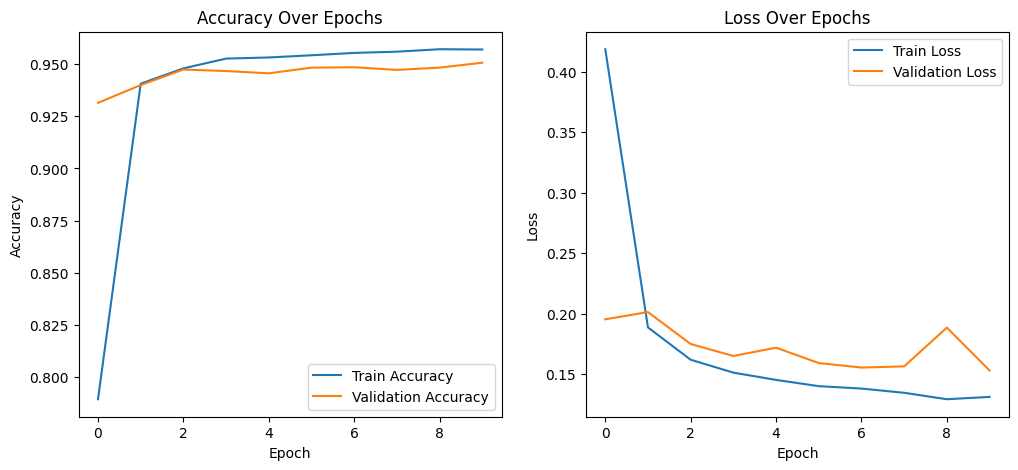

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [ ]:
val_data = val_gen.flow_from_directory(
    '/content/cell_images',
    target_size=(64, 64),
    batch_size=32,
    class_mode='binary',
    subset='validation',
    shuffle=False   # ✅ Important!
)


Found 5510 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


173/173 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step


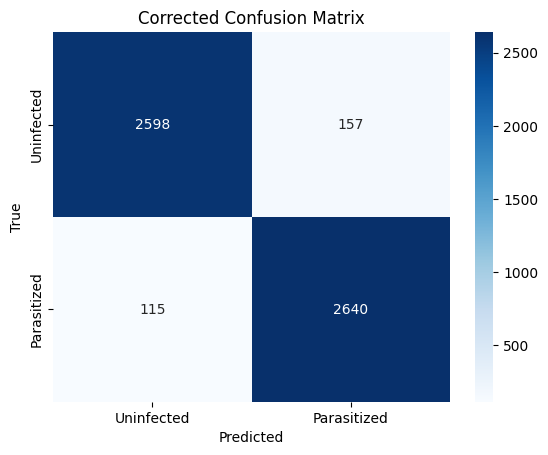

              precision    recall  f1-score   support

  Uninfected       0.96      0.94      0.95      2755
 Parasitized       0.94      0.96      0.95      2755

    accuracy                           0.95      5510
   macro avg       0.95      0.95      0.95      5510
weighted avg       0.95      0.95      0.95      5510



In [ ]:
y_pred = (model.predict(val_data) > 0.5).astype("int32")
y_true = val_data.classes

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uninfected', 'Parasitized'],
            yticklabels=['Uninfected', 'Parasitized'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Corrected Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=['Uninfected', 'Parasitized']))
